In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as pyplot

In [2]:
from google.colab import files

uploaded = files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [3]:
df = pd.read_csv ("dirty_cafe_sales.csv")

In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [6]:
df.shape

(10000, 8)

In [7]:
df.dtypes

,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


In [8]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].head(10)

,Quantity,Price Per Unit,Total Spent
0,2,2.0,4.0
1,4,3.0,12.0
2,4,1.0,ERROR
3,2,5.0,10.0
4,2,2.0,4.0
5,5,4.0,20.0
6,3,3.0,9.0
7,4,4.0,16.0
8,5,3.0,15.0
9,5,4.0,20.0


In [9]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [10]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].head(10)

,Quantity,Price Per Unit,Total Spent
0,2.0,2.0,4.0
1,4.0,3.0,12.0
2,4.0,1.0,NaN
3,2.0,5.0,10.0
4,2.0,2.0,4.0
5,5.0,4.0,20.0
6,3.0,3.0,9.0
7,4.0,4.0,16.0
8,5.0,3.0,15.0
9,5.0,4.0,20.0


In [11]:
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

/tmp/ipykernel_1569/487052630.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(), inplace=True)


In [12]:
df['Price Per Unit'].fillna(df['Price Per Unit'].median(), inplace=True)

/tmp/ipykernel_1569/1032530248.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Price Per Unit'].fillna(df['Price Per Unit'].median(), inplace=True)


In [13]:
df['Total Spent'].fillna(df['Total Spent'].median(), inplace=True)

/tmp/ipykernel_1569/3449142576.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Spent'].fillna(df['Total Spent'].median(), inplace=True)


In [14]:
df.isnull().sum()

,0
Transaction ID,0
Item,333
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,2579
Location,3265
Transaction Date,159


In [15]:
df['Item'].fillna(df['Item'].mode()[0], inplace=True)
df['Transaction Date'].fillna(df['Transaction Date'].mode()[0], inplace=True)

/tmp/ipykernel_1569/195071193.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item'].fillna(df['Item'].mode()[0], inplace=True)
/tmp/ipykernel_1569/195071193.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [16]:
df.isnull().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,2579
Location,3265
Transaction Date,0


In [17]:
df['Payment Method'].fillna('Unknown', inplace=True)
df.drop(columns=['Location'], inplace=True)

/tmp/ipykernel_1569/3038896757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('Unknown', inplace=True)


In [18]:
df.shape

(10000, 7)

In [19]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary[col] = len(outlier)

print("Jumlah Outlier per Kolom:")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Jumlah Outlier per Kolom:
Quantity: 0
Price Per Unit: 0
Total Spent: 259


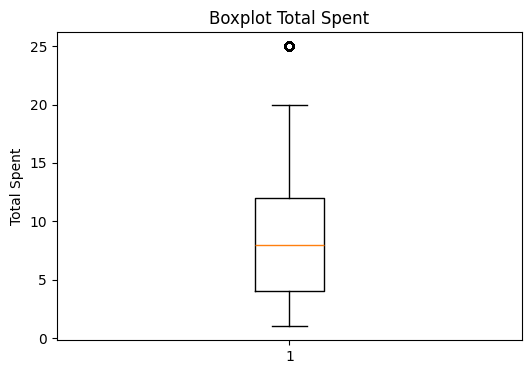

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df['Total Spent'].dropna())
plt.title('Boxplot Total Spent')
plt.ylabel('Total Spent')
plt.show()

                Quantity  Price Per Unit  Total Spent
Quantity        1.000000        0.005913     0.668821
Price Per Unit  0.005913        1.000000     0.612374
Total Spent     0.668821        0.612374     1.000000


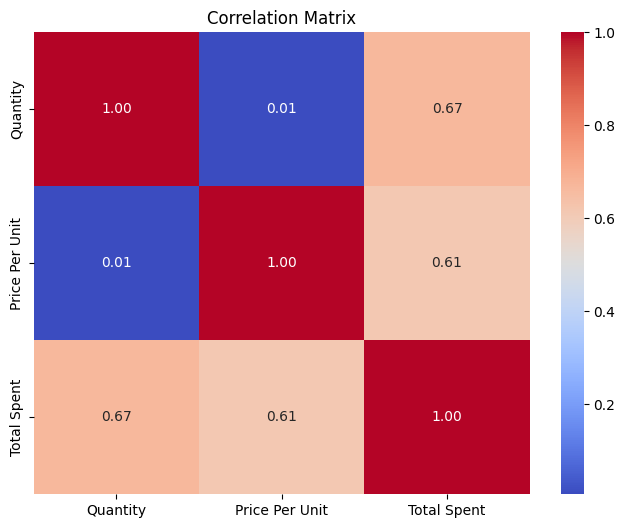

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Buat matriks korelasi
corr_matrix = df[numerical_cols].corr()

# Tampilkan matriks korelasi
print(corr_matrix)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()